In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("BTC-USD.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


In [5]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [6]:
df = df[['Date', 'Close']]

df.head()

,Date,Close
0,2014-09-17,457.334015
1,2014-09-18,424.440002
2,2014-09-19,394.795990
3,2014-09-20,408.903992
4,2014-09-21,398.821014


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()


,Date,Close
0,2014-09-17,457.334015
1,2014-09-18,424.440002
2,2014-09-19,394.795990
3,2014-09-20,408.903992
4,2014-09-21,398.821014


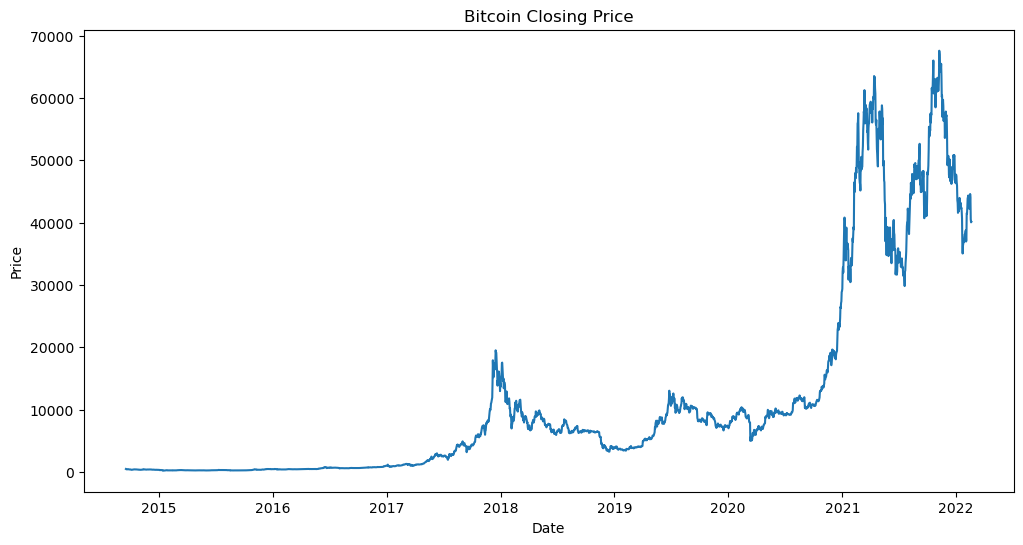

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [9]:
df['Target'] = df['Close'].shift(-1)

df.head()

,Date,Close,Target
0,2014-09-17,457.334015,424.440002
1,2014-09-18,424.440002,394.795990
2,2014-09-19,394.795990,408.903992
3,2014-09-20,408.903992,398.821014
4,2014-09-21,398.821014,402.152008


In [10]:

df.dropna(inplace=True)


In [11]:
X = df[['Close']]
y = df['Target']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
predictions = model.predict(X_test)

predictions[:5]

array([11357.5053046 , 11479.49656761, 11314.85095496, 11533.52820438,
       11497.96260734])

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1123.5150397659254
R2 Score: 0.9894610082462135


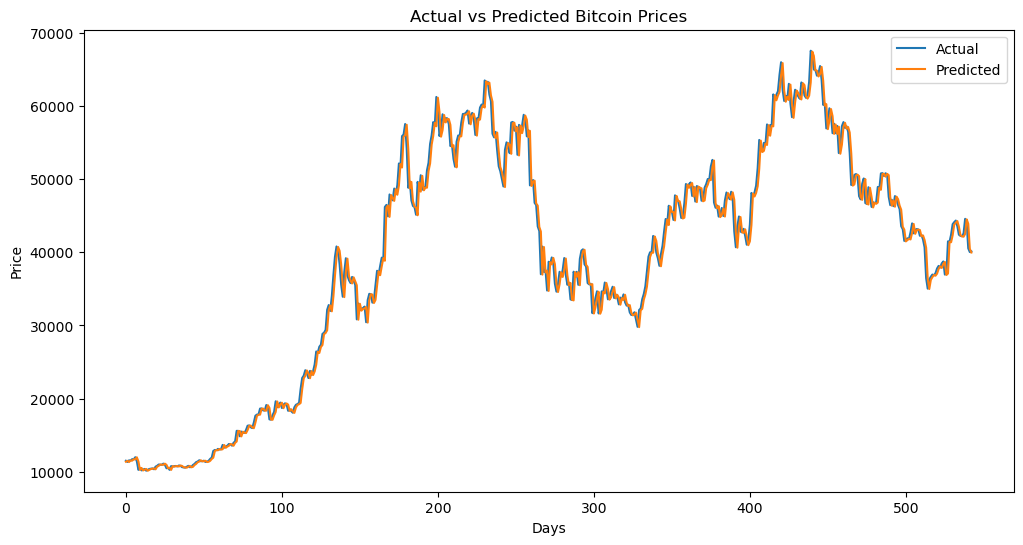

In [16]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title("Actual vs Predicted Bitcoin Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

plt.show()

In [17]:
import joblib

joblib.dump(model, "bitcoin_model.pkl")

print("Model saved successfully")

Model saved successfully


In [18]:
latest_price = X.iloc[-1].values.reshape(1, -1)

prediction = model.predict(latest_price)

print("Predicted next day Bitcoin price:", prediction[0])

Predicted next day Bitcoin price: 39966.70713260987


C:\Users\raiha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
